# From Dataset to Master Thesis Topic — `robo_ai_u_r5e`

This notebook walks through the dataset **step by step** and ends with a ranked list of thesis topics that the data can actually support.

| Step | What you learn | Why it matters for the thesis |
|---|---|---|
| 1 | Metadata, size, splits | Is the dataset big enough for deep learning? |
| 2 | Full feature tree | What is recorded (cameras, joints, actions, language, rewards)? |
| 3 | Role of every field | Inputs vs. targets → which learning problems are possible |
| 4 | Episode scan | Number and length of demonstrations |
| 5 | Language instructions | Single-task or multi-task / language-conditioned? |
| 6 | Camera frames | Viewpoints, resolution, scene variety |
| 7 | Robot state trajectories | Proprioception quality, smoothness, force/torque |
| 8 | Action analysis | Action space (absolute vs. delta, gripper), idle phases |
| 9 | Rewards / success labels | Is RL or failure detection possible? |
| 10 | Data quality | NaNs, short episodes, outliers |
| 11 | **Automatic feasibility report** | Which thesis topics fit this data |
| 12 | Sanity-check baseline | Is there a learnable signal (state → action)? |
| 13 | Dataset card | Text you can paste into your thesis proposal |

> **Note on the format.** Robot datasets loaded with `tfds.builder_from_directory` are usually stored in **RLDS** format (as used by Open X-Embodiment):
> each element of `ds` is an **episode** with a nested `steps` dataset, and every step holds `observation`, `action`, `reward`, `is_first`, `is_last`, `is_terminal` and often `language_instruction`.
> The notebook detects this automatically, and falls back to a flat layout if the dataset is not RLDS.

## Step 0 — Setup

Install the packages once (uncomment the line below), then set `DATASET_PATH` to the folder that contains `dataset_info.json`, `features.json` and the `*.tfrecord*` files.

The dataset is published at <https://huggingface.co/datasets/Rouhis/RoboAI_UR5e> (~26 GB, 256 shards). You don't need all of it for exploration: download the two JSON files plus the first *k* shards, and the notebook will automatically read only the episodes in those shards.

In [1]:
# %pip install tensorflow tensorflow-datasets matplotlib pandas tqdm

import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Exploration does not need the GPU; hiding it avoids TensorFlow reserving all GPU memory.
try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)
print("TensorFlow", tf.__version__, "| TFDS", tfds.__version__)

TensorFlow 2.21.0 | TFDS 4.9.10


C:\Users\Nahid\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# >>> EDIT THIS <<<  (a raw string r"..." keeps Windows backslashes intact)
DATASET_PATH = r"C:\Users\Nahid\Test\dataset"

# How many episodes to scan for statistics. Start with ~200; set to None to scan everything.
MAX_EPISODES = 200
SEED = 0

if not os.path.exists(os.path.join(DATASET_PATH, "dataset_info.json")):
    raise FileNotFoundError(
        f"No dataset_info.json found in {DATASET_PATH!r}. "
        "Point DATASET_PATH to the version folder, e.g. ...\\robo_ai_u_r5e\\1.0.0"
    )

## Step 1 — Load the dataset and read its metadata

The description and citation often already tell you what the dataset was collected for (e.g. teleoperated pick-and-place, kitting, assembly). Read them — they are the starting point for your "related work" chapter.

In [3]:
builder = tfds.builder_from_directory(DATASET_PATH)
info = builder.info

print("Name:       ", info.name)
print("Version:    ", info.version)
print("Homepage:   ", info.homepage)
print("Size on disk:", info.dataset_size)
print()
for split_name, split in info.splits.items():
    print(f"Split {split_name!r}: {split.num_examples} examples (episodes) in {split.num_shards} shards")
print("\nDescription:\n", info.description or "(none)")
print("\nCitation:\n", info.citation or "(none)")

TOTAL_EPISODES = info.splits["train"].num_examples

# If only the first k .tfrecord files are downloaded, read only the episodes stored in them.
train_info = info.splits["train"]
available = 0
for i, n in enumerate(train_info.shard_lengths):
    shard = f"{info.name}-train.tfrecord-{i:05d}-of-{train_info.num_shards:05d}"
    if not os.path.exists(os.path.join(DATASET_PATH, shard)):
        break
    available += n
if available == 0:
    raise FileNotFoundError("The first .tfrecord shard is missing; download the data files first.")
SPLIT = "train" if available == TOTAL_EPISODES else f"train[:{available}]"
print(f"\nEpisodes available locally: {available} of {TOTAL_EPISODES} -> using split {SPLIT!r}")

ds = builder.as_dataset(split=SPLIT)

Name:        robo_ai_u_r5e
Version:     1.0.0
Homepage:    https://sites.google.com/view/roboai-ur5e/home
Size on disk: 24.07 GiB

Split 'train': 443 examples (episodes) in 256 shards

Description:
 Real-world robotic demonstrations collected from UR5e for language-conditioned manipulation

Citation:
 @dataset{Joonas_Rouhiainen_2025,
  author       = {Joonas Rouhiainen},
  title        = {RoboAI UR5e Dataset},
  institution  = {RoboAI Research Center, Satakunta University of Applied Sciences},
  year         = {2025},
}

Episodes available locally: 52 of 443 -> using split 'train[:52]'


## Step 2 — Print the full feature tree

This is the single most important cell. It shows **everything** that is recorded, including nested fields inside `steps` and `observation`.

In [4]:
def print_feature_tree(feature, name="episode", indent=0):
    pad = "    " * indent
    if isinstance(feature, tfds.features.FeaturesDict):
        print(f"{pad}{name}/")
        for key, sub in feature.items():
            print_feature_tree(sub, key, indent + 1)
    elif isinstance(feature, tfds.features.Sequence):  # tfds.features.Dataset is a subclass
        kind = "Dataset (RLDS steps)" if isinstance(feature, tfds.features.Dataset) else "Sequence"
        print(f"{pad}{name}/  [{kind}]")
        print_feature_tree(feature.feature, "<each step>", indent + 1)
    else:
        doc = getattr(feature, "doc", None)
        desc = getattr(doc, "desc", "") if doc is not None else ""
        desc = f"   # {desc}" if desc else ""
        print(f"{pad}{name}: {type(feature).__name__} shape={feature.shape} dtype={feature.dtype}{desc}")

print_feature_tree(info.features)

episode/
    episode_metadata/
        file_name: Text shape=() dtype=<dtype: 'string'>
        episode_index: Tensor shape=() dtype=<dtype: 'int32'>
    steps/  [Dataset (RLDS steps)]
        <each step>/
            absolute_action_mask: Tensor shape=(7,) dtype=<dtype: 'bool'>
            action_normalization_mask: Tensor shape=(7,) dtype=<dtype: 'bool'>
            observation/
                image: Image shape=(480, 640, 3) dtype=<dtype: 'uint8'>
                robot_state: Tensor shape=(15,) dtype=<dtype: 'float32'>
            language_instruction: Text shape=() dtype=<dtype: 'string'>
            action: Tensor shape=(7,) dtype=<dtype: 'float32'>


## Step 3 — Assign a role to every field

Each field is sorted into a role:

- **RGB camera / depth** → inputs for perception and visuomotor policies
- **state** (joint positions, end-effector pose, gripper, force/torque) → proprioceptive input
- **action** → the prediction target for imitation learning
- **language** → task description, enables language-conditioned or multi-task learning
- **reward / is_terminal** → enables offline RL or success detection
- **action masks** (`absolute_action_mask`, `action_normalization_mask`) → say which action dimensions are absolute (e.g. the gripper) and which should be normalized; this is the format expected by Octo-style fine-tuning pipelines

In [5]:
def flatten_dict(d, prefix=""):
    """{"a": {"b": x}} -> {"a/b": x}. Works for element_specs and for numpy steps."""
    out = {}
    for k, v in d.items():
        if isinstance(v, dict):
            out.update(flatten_dict(v, f"{prefix}{k}/"))
        else:
            out[f"{prefix}{k}"] = v
    return out

episode_spec = ds.element_spec
IS_RLDS = isinstance(episode_spec, dict) and "steps" in episode_spec
if IS_RLDS:
    step_spec = episode_spec["steps"].element_spec
    episode_meta_spec = {k: v for k, v in episode_spec.items() if k != "steps"}
else:
    print("Dataset is NOT in RLDS format; every example is treated as one time step.")
    step_spec, episode_meta_spec = episode_spec, {}

step_leaves = flatten_dict(step_spec)
meta_leaves = flatten_dict(episode_meta_spec)

LANG_TOKENS = ("language", "instruction", "task", "prompt", "text")
FORCE_TOKENS = ("force", "torque", "wrench", "effort")

def is_numeric(spec):
    return isinstance(spec, tf.TensorSpec) and (spec.dtype.is_floating or spec.dtype.is_integer or spec.dtype == tf.bool)

DEPTH_KEYS = [p for p, s in step_leaves.items()
              if "depth" in p.lower() and is_numeric(s) and s.shape.rank in (2, 3)]
RGB_KEYS = [p for p, s in step_leaves.items()
            if p not in DEPTH_KEYS and s.dtype == tf.uint8 and s.shape.rank == 3 and s.shape[-1] in (3, 4)]
IMAGE_KEYS = RGB_KEYS + DEPTH_KEYS

LANG_KEYS = [p for p, s in step_leaves.items()
             if s.dtype == tf.string and any(t in p.lower() for t in LANG_TOKENS)]
META_LANG_KEYS = [p for p, s in meta_leaves.items()
                  if isinstance(s, tf.TensorSpec) and s.dtype == tf.string and any(t in p.lower() for t in LANG_TOKENS)]

def is_vector(path, spec):
    return (is_numeric(spec) and path not in IMAGE_KEYS and spec.shape.rank is not None
            and spec.shape.rank <= 1 and "embedding" not in path.lower())

ACTION_KEYS = [p for p, s in step_leaves.items() if p.split("/")[0] == "action" and is_vector(p, s)]
STATE_KEYS = [p for p, s in step_leaves.items() if p.startswith("observation/") and is_vector(p, s)]
FORCE_KEYS = [p for p in STATE_KEYS if any(t in p.lower() for t in FORCE_TOKENS)]
REWARD_KEY = "reward" if "reward" in step_leaves else None

def dim_names(keys):
    names = []
    for k in keys:
        n = step_leaves[k].shape.num_elements() or 1
        names += [k] if n == 1 else [f"{k}[{i}]" for i in range(n)]
    return names

STATE_NAMES, ACTION_NAMES = dim_names(STATE_KEYS), dim_names(ACTION_KEYS)

def role_of(path):
    if path in RGB_KEYS: return "RGB camera"
    if path in DEPTH_KEYS: return "depth"
    if path in FORCE_KEYS: return "state (force/torque)"
    if path in STATE_KEYS: return "state"
    if path in ACTION_KEYS: return "action (target)"
    if path in LANG_KEYS: return "language"
    if path == REWARD_KEY: return "reward"
    if path in ("is_first", "is_last", "is_terminal", "discount"): return "RLDS bookkeeping"
    if "embedding" in path.lower(): return "precomputed embedding"
    if "mask" in path.lower(): return "action metadata (mask)"
    return "other"

roles = pd.DataFrame(
    [{"level": "step", "field": p, "shape": tuple(s.shape) if hasattr(s, "shape") else "-",
      "dtype": s.dtype.name if hasattr(s, "dtype") else type(s).__name__, "role": role_of(p)}
     for p, s in step_leaves.items()]
    + [{"level": "episode", "field": p, "shape": tuple(s.shape) if hasattr(s, "shape") else "-",
        "dtype": s.dtype.name if hasattr(s, "dtype") else type(s).__name__, "role": "episode metadata"}
       for p, s in meta_leaves.items()]
)
display(roles)
print(f"RLDS: {IS_RLDS} | cameras: {RGB_KEYS} | depth: {DEPTH_KEYS}")
print(f"state dims: {len(STATE_NAMES)} | action dims: {len(ACTION_NAMES)} | language: {LANG_KEYS or META_LANG_KEYS}")

,level,field,shape,dtype,role
0,step,absolute_action_mask,"(7,)",bool,action metadata (mask)
1,step,action,"(7,)",float32,action (target)
2,step,action_normalization_mask,"(7,)",bool,action metadata (mask)
3,step,language_instruction,(),string,language
4,step,observation/image,"(480, 640, 3)",uint8,RGB camera
5,step,observation/robot_state,"(15,)",float32,state
6,episode,episode_metadata/episode_index,(),int32,episode metadata
7,episode,episode_metadata/file_name,(),string,episode metadata


RLDS: True | cameras: ['observation/image'] | depth: []
state dims: 15 | action dims: 7 | language: ['language_instruction']


## Step 4 — Scan the episodes (fast, without decoding images)

Decoding JPEGs is the slow part, so for statistics the images are skipped with `tfds.decode.SkipDecoding()`. Only states, actions, rewards, instructions and metadata are loaded into memory.

In [6]:
def skip_image_decoders(feature):
    if isinstance(feature, tfds.features.FeaturesDict):
        sub = {k: skip_image_decoders(v) for k, v in feature.items()}
        sub = {k: v for k, v in sub.items() if v is not None}
        return sub or None
    if isinstance(feature, tfds.features.Sequence):
        return skip_image_decoders(feature.feature)
    if isinstance(feature, tfds.features.Image):
        return tfds.decode.SkipDecoding()
    return None

try:
    ds_fast = builder.as_dataset(split=SPLIT, decoders=skip_image_decoders(info.features))
except Exception as e:
    print("SkipDecoding not possible, using the normal (slower) dataset:", e)
    ds_fast = ds

def get_path(d, path):
    for p in path.split("/"):
        d = d[p]
    return d

def to_vector(step, keys):
    if not keys:
        return np.zeros(0, np.float32)
    return np.concatenate([np.asarray(get_path(step, k), dtype=np.float32).reshape(-1) for k in keys])

def to_text(x):
    x = np.asarray(x)
    if x.size == 0:
        return ""
    x = x.reshape(-1)[0]
    return x.decode("utf-8", errors="replace") if isinstance(x, bytes) else str(x)

def iterate_episodes(dataset, limit):
    """Yields (list_of_numpy_steps, episode_metadata_dict)."""
    dataset = dataset if limit is None else dataset.take(limit)
    if IS_RLDS:
        for episode in dataset:
            meta = {k: v for k, v in episode.items() if k != "steps"}
            yield list(tfds.as_numpy(episode["steps"])), tf.nest.map_structure(lambda t: t.numpy(), meta)
    else:
        yield list(tfds.as_numpy(dataset)), {}

episodes = []
for steps, meta in tqdm(iterate_episodes(ds_fast, MAX_EPISODES), desc="scanning episodes"):
    if not steps:
        continue
    meta = flatten_dict(meta)
    rec = {
        "length": len(steps),
        "state": np.stack([to_vector(s, STATE_KEYS) for s in steps]),
        "action": np.stack([to_vector(s, ACTION_KEYS) for s in steps]),
        "reward": np.array([float(np.sum(get_path(s, REWARD_KEY))) for s in steps]) if REWARD_KEY else None,
        "instruction": None,
        "terminal": bool(steps[-1]["is_terminal"]) if "is_terminal" in step_leaves else None,
        "meta": meta,
    }
    if LANG_KEYS:
        rec["instruction"] = to_text(get_path(steps[0], LANG_KEYS[0]))
    elif META_LANG_KEYS:
        rec["instruction"] = to_text(meta[META_LANG_KEYS[0]])
    episodes.append(rec)

rows = []
for i, e in enumerate(episodes):
    row = {"episode": i, "length": e["length"], "instruction": e["instruction"],
           "return": e["reward"].sum() if e["reward"] is not None else np.nan, "terminal": e["terminal"]}
    for k, v in e["meta"].items():
        v = np.asarray(v)
        if v.size == 1:
            row["meta/" + k] = to_text(v) if v.dtype.kind in "SUO" else v.item()
    rows.append(row)
ep_df = pd.DataFrame(rows)

print(f"Scanned {len(episodes)} of {TOTAL_EPISODES} episodes, {ep_df['length'].sum()} steps in total.")
display(ep_df.head(10))

scanning episodes: 0it [00:00, ?it/s]

scanning episodes: 1it [00:00,  1.27it/s]

scanning episodes: 2it [00:00,  2.36it/s]

scanning episodes: 5it [00:01,  6.64it/s]

scanning episodes: 9it [00:01, 12.08it/s]

...

scanning episodes: 47it [00:02, 28.39it/s]

scanning episodes: 50it [00:02, 26.96it/s]

scanning episodes: 52it [00:02, 18.68it/s]

Scanned 52 of 443 episodes, 6734 steps in total.


,episode,length,instruction,return,terminal,meta/episode_metadata/episode_index,meta/episode_metadata/file_name
0,0,173,stack the cups,NaN,None,299,stack_the_cups_20250728_102449_EDITED.npz
1,1,207,pick and place the blue cylinder and the yellow block in to the box,NaN,None,18,pick_and_place_the_blue_cylinder_and_the_yellow_block_in_to_the_box_20250708_144010_EDITED.npz
2,2,154,stack the cups,NaN,None,304,stack_the_cups_20250728_103833_EDITED.npz
3,3,118,stack the blocks,NaN,None,206,stack_the_blocks_20250813_122754.npz
4,4,89,stack the cups,NaN,None,271,stack_the_cups_20250725_103737_EDITED.npz
5,5,114,stack the cups,NaN,None,403,stack_the_cups_20250731_145835.npz
6,6,117,stack the cups,NaN,None,244,stack_the_cups_20250724_122313_EDITED.npz
7,7,107,pick and place the cups inside each other,NaN,None,20,pick_and_place_the_cups_inside_each_other_20250724_123659_EDITED.npz
8,8,120,stack cups,NaN,None,114,stack_cups_20250728_131649_EDITED.npz
9,9,114,stack cups,NaN,None,102,stack_cups_20250724_125707_EDITED.npz


## Step 5 — Episode lengths

Rough rules of thumb for a thesis:
- **< 100 episodes**: prefer fine-tuning pretrained models, few-shot learning or data-efficiency studies.
- **100–1,000 episodes**: enough for task-specific imitation learning (Diffusion Policy, ACT).
- **> 1,000 episodes**: training larger multi-task policies or world models becomes realistic.

Set `CONTROL_HZ` if you know the recording frequency (check the description or ask the dataset authors) to convert steps into seconds.

count     52.0
mean     129.5
std       34.4
min       89.0
25%      107.8
50%      119.0
75%      139.8
max      299.0
Name: length, dtype: float64


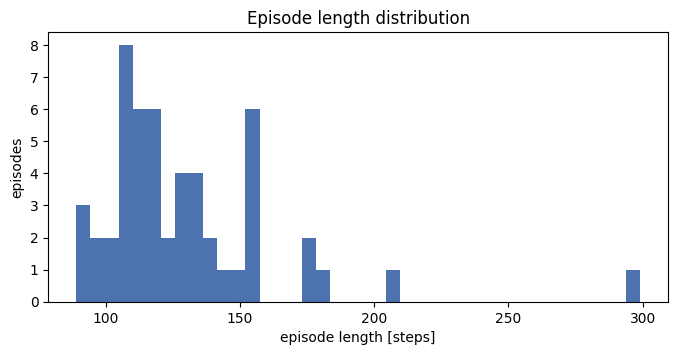

In [7]:
CONTROL_HZ = None   # e.g. 10 or 30

print(ep_df["length"].describe().round(1))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ep_df["length"], bins=40, color="#4C72B0")
ax.set_xlabel("episode length [steps]"); ax.set_ylabel("episodes"); ax.set_title("Episode length distribution")
plt.show()

if CONTROL_HZ:
    total_h = ep_df["length"].sum() / CONTROL_HZ / 3600 * TOTAL_EPISODES / max(len(episodes), 1)
    print(f"Estimated total robot time in the full dataset: {total_h:.1f} hours")

## Step 6 — Language instructions

Many unique instructions mean the dataset is **multi-task**, which enables language-conditioned policies or generalization studies (held-out instructions or objects). A single instruction means a single-task dataset, where the thesis focus is better placed on precision, robustness or data efficiency.

20 unique instructions in 52 episodes
Average instruction length: 4.6 words


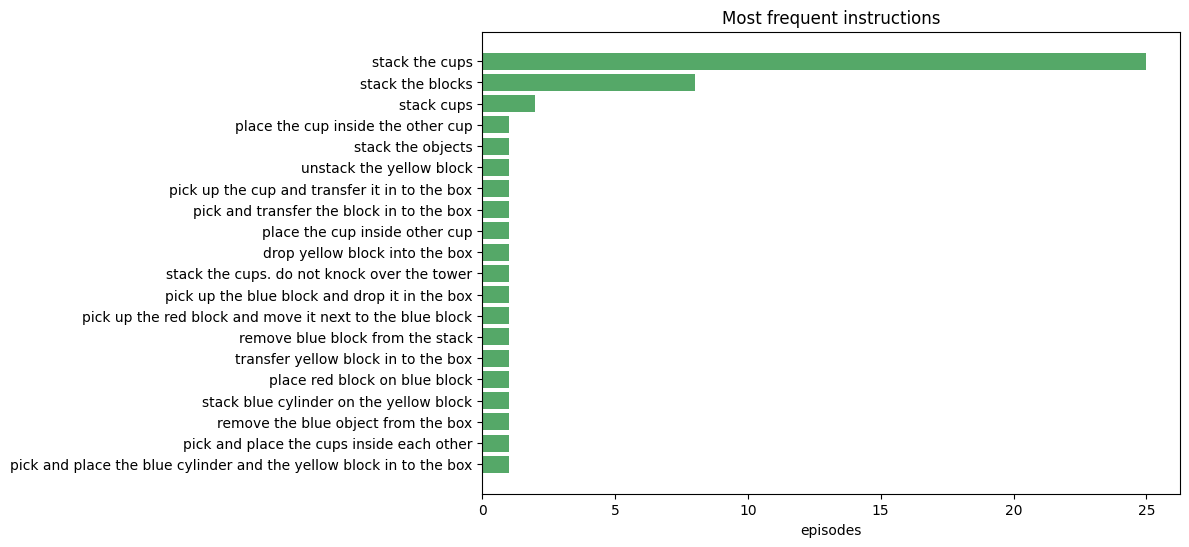

Task families (first word of the instruction): [('stack', 38), ('pick', 6), ('place', 3), ('remove', 2), ('transfer', 1), ('drop', 1), ('unstack', 1)]


In [8]:
instr = ep_df["instruction"].dropna()
instr = instr[instr.str.strip() != ""]
N_UNIQUE_INSTR = instr.nunique()

if N_UNIQUE_INSTR == 0:
    print("No language instructions found -> the dataset is probably single-task or unlabeled.")
else:
    counts = Counter(instr)
    print(f"{N_UNIQUE_INSTR} unique instructions in {len(instr)} episodes")
    print(f"Average instruction length: {instr.str.split().str.len().mean():.1f} words")
    top = pd.Series(counts).sort_values(ascending=True).tail(25)
    fig, ax = plt.subplots(figsize=(9, max(3, 0.3 * len(top))))
    ax.barh(top.index, top.values, color="#55A868")
    ax.set_xlabel("episodes"); ax.set_title("Most frequent instructions")
    plt.show()

    verbs = Counter(s.split()[0].lower() for s in instr if s.split())
    print("Task families (first word of the instruction):", verbs.most_common(15))

## Step 7 — Camera frames

Check: How many viewpoints (third-person, wrist)? What resolution? Does the scene change (objects, backgrounds, lighting) across episodes? Scene variety decides whether a **generalization** thesis is possible.

observation/image: shape (480, 640, 3)


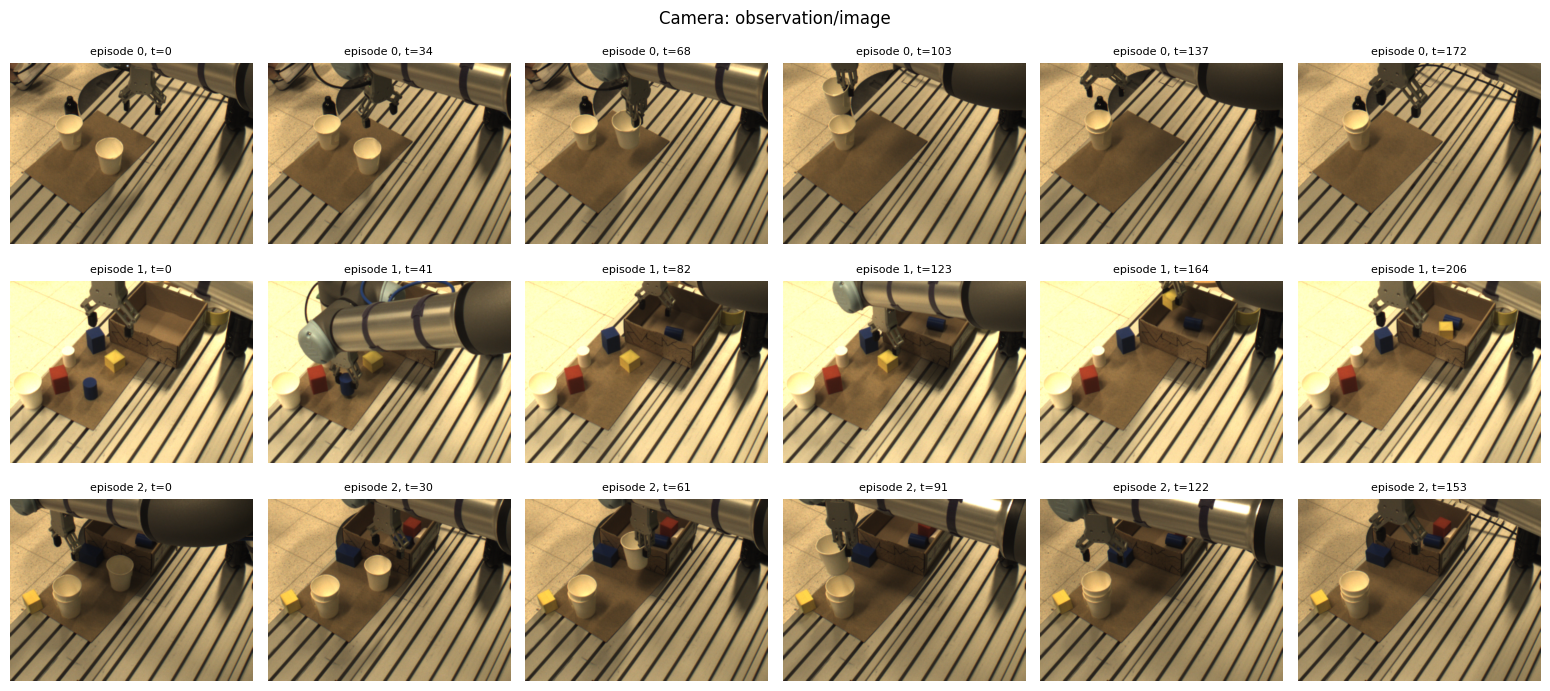

In [9]:
N_VIS_EPISODES = 3
FRAMES_PER_EPISODE = 6

if not IMAGE_KEYS:
    print("No image fields found.")
else:
    for k in IMAGE_KEYS:
        print(f"{k}: shape {tuple(step_leaves[k].shape)}")
    vis = [steps for steps, _ in iterate_episodes(ds, N_VIS_EPISODES) if steps]
    for key in IMAGE_KEYS:
        fig, axes = plt.subplots(len(vis), FRAMES_PER_EPISODE,
                                 figsize=(2.6 * FRAMES_PER_EPISODE, 2.4 * len(vis)), squeeze=False)
        for r, steps in enumerate(vis):
            for c, t in enumerate(np.linspace(0, len(steps) - 1, FRAMES_PER_EPISODE).astype(int)):
                img = np.asarray(get_path(steps[t], key))
                if img.ndim == 3 and img.shape[-1] == 1:
                    img = img[..., 0]
                axes[r, c].imshow(img, cmap=None if img.ndim == 3 else "viridis")
                axes[r, c].set_title(f"episode {r}, t={t}", fontsize=8)
                axes[r, c].axis("off")
        fig.suptitle(f"Camera: {key}")
        plt.tight_layout(); plt.show()

## Step 8 — Robot state trajectories

UR5e datasets typically record 6 joint angles, the TCP pose (xyz + rotation) and a gripper state; some also record a force/torque sensor. Smooth curves indicate clean teleoperation data. Force/torque channels open up contact-rich topics (insertion, anomaly detection).

Force/torque channels: none


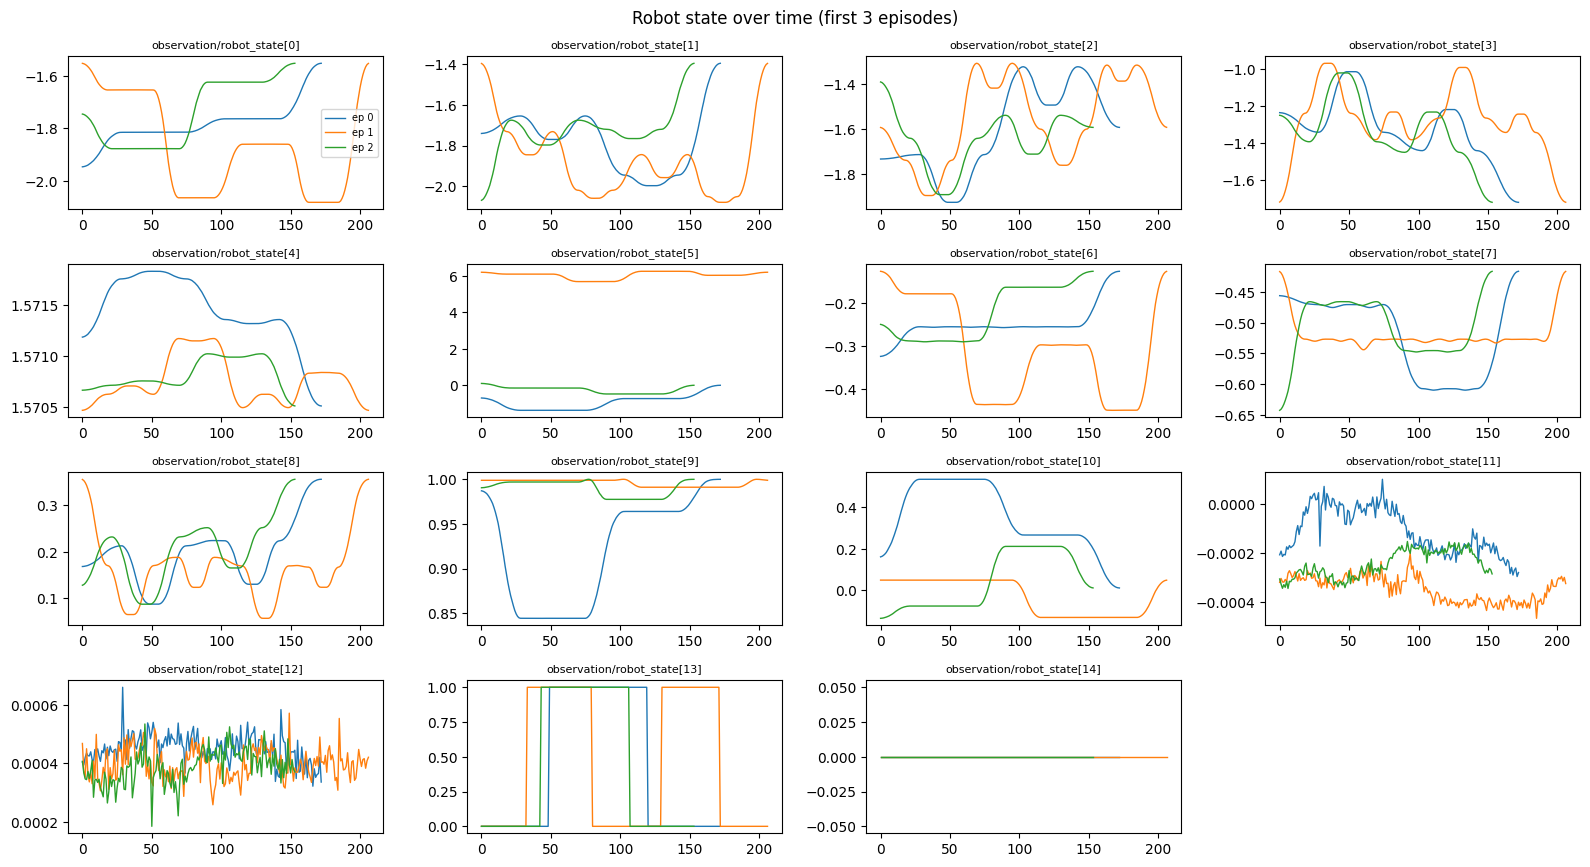

In [10]:
def plot_dims(arrays, names, title, max_dims=16):
    d = min(len(names), max_dims)
    if d == 0:
        print(f"{title}: nothing to plot"); return
    cols = 4
    rows = int(np.ceil(d / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.2 * rows), squeeze=False)
    for i in range(d):
        ax = axes.flat[i]
        for j, arr in enumerate(arrays):
            ax.plot(arr[:, i], lw=1, label=f"ep {j}")
        ax.set_title(names[i], fontsize=8)
    for ax in list(axes.flat)[d:]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()

print("Force/torque channels:", FORCE_KEYS or "none")
plot_dims([e["state"] for e in episodes[:3]], STATE_NAMES, "Robot state over time (first 3 episodes)")

## Step 9 — Action analysis

Things to find out:
1. **Per-dimension statistics.** Dimensions with only 2–3 unique values are usually the **gripper** (open/close).
2. **Absolute vs. delta actions.** If actions correlate strongly with the *next state*, they are absolute targets; if they correlate with the *state change*, they are delta commands. This affects the model design and belongs in the thesis methodology.
3. **Idle steps.** A high share of repeated actions means pauses in the demonstrations, which you may want to filter out.

,count,mean,std,min,25%,50%,75%,max,n_unique,discrete (gripper?)
action[0],6734.0,-0.0000,0.0051,-0.0282,-0.0002,-0.0,0.0001,0.0296,6683,False
action[1],6734.0,-0.0001,0.0045,-0.0232,-0.0007,-0.0,0.0006,0.0215,6682,False
action[2],6734.0,-0.0000,0.0070,-0.0226,-0.0037,0.0,0.0037,0.0225,6683,False
action[3],6734.0,-0.0011,0.3206,-5.2538,-0.0002,0.0,0.0001,5.2607,6683,False
action[4],6734.0,0.0001,0.3223,-5.1322,-0.0001,0.0,0.0002,5.1323,6682,False
action[5],6734.0,0.0000,0.0002,-0.0033,-0.0000,0.0,0.0000,0.0034,6683,False
action[6],6734.0,0.4434,0.4968,0.0000,0.0000,0.0,1.0000,1.0000,2,True


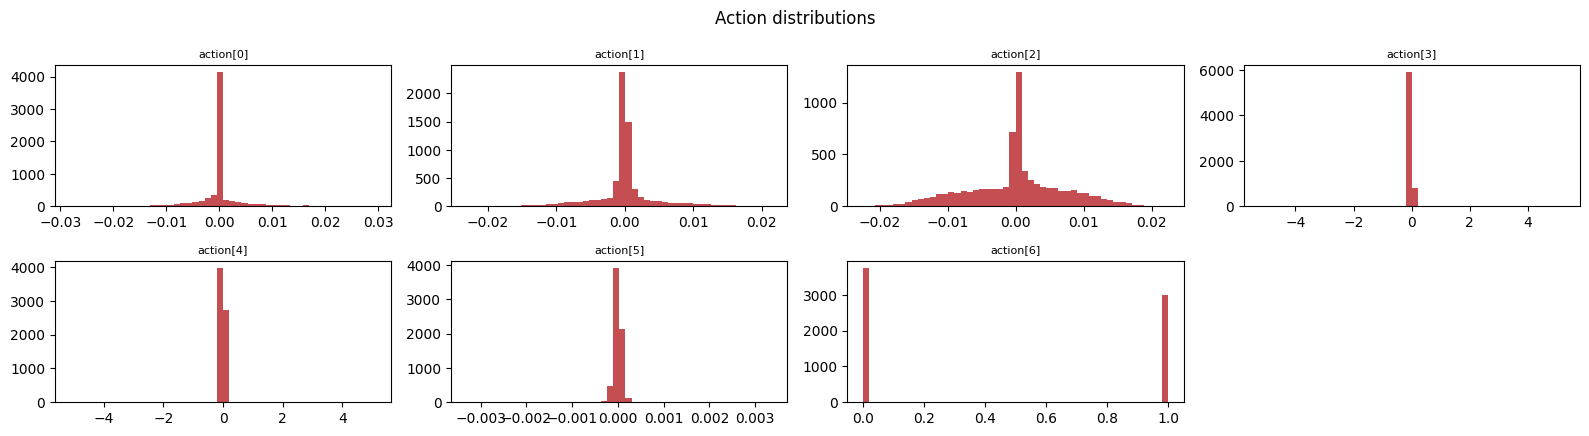

Share of steps that repeat the previous action (idle): 0.0%


In [11]:
A = np.concatenate([e["action"] for e in episodes]) if episodes else np.zeros((0, 0))
S = np.concatenate([e["state"] for e in episodes]) if episodes else np.zeros((0, 0))

if A.shape[1] == 0:
    print("No numeric action fields found.")
else:
    act_stats = pd.DataFrame(A, columns=ACTION_NAMES).describe().T
    act_stats["n_unique"] = [len(np.unique(A[:, i])) for i in range(A.shape[1])]
    act_stats["discrete (gripper?)"] = act_stats["n_unique"] <= 3
    display(act_stats.round(4))

    d = min(A.shape[1], 16)
    cols = 4
    rows = int(np.ceil(d / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.2 * rows), squeeze=False)
    for i in range(d):
        axes.flat[i].hist(A[:, i], bins=50, color="#C44E52")
        axes.flat[i].set_title(ACTION_NAMES[i], fontsize=8)
    for ax in list(axes.flat)[d:]:
        ax.axis("off")
    fig.suptitle("Action distributions"); plt.tight_layout(); plt.show()

    repeat = [np.mean(np.all(np.isclose(e["action"][1:], e["action"][:-1]), axis=1))
              for e in episodes if e["length"] > 1]
    print(f"Share of steps that repeat the previous action (idle): {np.mean(repeat):.1%}")

In [12]:
def col_corr(X, Y):
    """Correlation between every column of X and every column of Y."""
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    Y = (Y - Y.mean(0)) / (Y.std(0) + 1e-8)
    return X.T @ Y / len(X)

pairs = [e for e in episodes if e["length"] > 1]
if A.shape[1] and S.shape[1] and pairs:
    Ac = np.concatenate([e["action"][:-1] for e in pairs])
    Sn = np.concatenate([e["state"][1:] for e in pairs])
    Sd = np.concatenate([e["state"][1:] - e["state"][:-1] for e in pairs])
    C_abs, C_del = np.abs(col_corr(Ac, Sn)), np.abs(col_corr(Ac, Sd))
    rel = []
    for i, name in enumerate(ACTION_NAMES):
        ja, jd = C_abs[i].argmax(), C_del[i].argmax()
        rel.append({"action dim": name,
                    "|corr| with next state": round(C_abs[i, ja], 2), "best state dim (abs)": STATE_NAMES[ja],
                    "|corr| with state change": round(C_del[i, jd], 2), "best state dim (delta)": STATE_NAMES[jd]})
    display(pd.DataFrame(rel))
    print("Heuristic: columns with high 'next state' correlation -> absolute actions; "
          "high 'state change' correlation -> delta/velocity actions.")
else:
    print("Need both state and action fields for this analysis.")

,action dim,|corr| with next state,best state dim (abs),|corr| with state change,best state dim (delta)
0,action[0],0.09,observation/robot_state[6],0.98,observation/robot_state[6]
1,action[1],0.10,observation/robot_state[7],0.98,observation/robot_state[7]
2,action[2],0.15,observation/robot_state[3],0.97,observation/robot_state[8]
3,action[3],0.04,observation/robot_state[11],0.59,observation/robot_state[9]
4,action[4],0.03,observation/robot_state[9],0.57,observation/robot_state[9]
5,action[5],0.04,observation/robot_state[9],0.57,observation/robot_state[11]
6,action[6],0.97,observation/robot_state[13],0.16,observation/robot_state[2]


Heuristic: columns with high 'next state' correlation -> absolute actions; high 'state change' correlation -> delta/velocity actions.


## Step 10 — Rewards and success labels

- **Sparse reward (0/1 at the end)** → success labels are available: success prediction and offline RL become possible.
- **All zeros** → pure demonstration data (typical for teleoperation). You can still create labels yourself, e.g. by annotating a subset of episodes.
- Metadata fields such as `success` or `failure` are very valuable: failed demonstrations are rare and enable **failure detection** topics.

In [13]:
SUCCESS_COLS = [c for c in ep_df.columns
                if any(t in c.lower() for t in ("success", "fail", "outcome", "label", "quality"))]
HAS_REWARD_SIGNAL = False

if REWARD_KEY:
    all_r = np.concatenate([e["reward"] for e in episodes])
    HAS_REWARD_SIGNAL = bool(all_r.std() > 0)
    print("Unique reward values (first 10):", np.unique(all_r)[:10])
    print(f"Non-zero reward steps: {np.mean(all_r != 0):.2%}")
    print(f"Episodes with positive return: {np.mean(ep_df['return'] > 0):.1%}")
else:
    print("No reward field.")

if ep_df["terminal"].notna().any():
    print(f"Episodes ending with is_terminal=True: {ep_df['terminal'].mean():.1%}")
print("Success-like metadata columns:", SUCCESS_COLS or "none")
for c in SUCCESS_COLS:
    print(ep_df[c].value_counts().head(10), "\n")

HAS_SUCCESS_LABEL = bool(SUCCESS_COLS) or (HAS_REWARD_SIGNAL and ep_df["return"].nunique() > 1)

No reward field.
Success-like metadata columns: none


## Step 11 — Data quality check

Problems found here can become a **thesis contribution** themselves, e.g. "How does demonstration quality affect policy performance?"

In [14]:
def outlier_share(X, k=6.0):
    if X.size == 0:
        return 0.0
    z = np.abs((X - X.mean(0)) / (X.std(0) + 1e-8))
    return float(np.mean(np.any(z > k, axis=1)))

quality = {
    "episodes scanned": len(episodes),
    "episodes with NaN/Inf in state": sum(int(not np.isfinite(e["state"]).all()) for e in episodes),
    "episodes with NaN/Inf in action": sum(int(not np.isfinite(e["action"]).all()) for e in episodes),
    "episodes shorter than 10 steps": int((ep_df["length"] < 10).sum()),
    "episodes with empty instruction": int(ep_df["instruction"].fillna("").str.strip().eq("").sum()) if (LANG_KEYS or META_LANG_KEYS) else "n/a",
    "steps with action outliers (>6 std)": f"{outlier_share(A):.2%}",
    "steps with state outliers (>6 std)": f"{outlier_share(S):.2%}",
}
display(pd.Series(quality, name="value").to_frame())

,value
episodes scanned,52
episodes with NaN/Inf in state,0
episodes with NaN/Inf in action,0
episodes shorter than 10 steps,0
episodes with empty instruction,0
steps with action outliers (>6 std),0.52%
steps with state outliers (>6 std),1.02%


## Step 12 — Automatic thesis feasibility report

Each candidate topic lists the data it **needs** (hard requirements) and data that makes it **stronger** (nice-to-have). The table ranks the topics by how well this dataset supports them.

In [15]:
flags = {
    "images": bool(RGB_KEYS),
    "multi_camera": len(RGB_KEYS) >= 2,
    "wrist_camera": any(t in k.lower() for k in RGB_KEYS for t in ("wrist", "hand", "gripper")),
    "depth": bool(DEPTH_KEYS),
    "state": bool(STATE_KEYS),
    "force_torque": bool(FORCE_KEYS),
    "actions": bool(ACTION_KEYS),
    "language": N_UNIQUE_INSTR > 0,
    "multi_task": N_UNIQUE_INSTR >= 5,
    "rewards": HAS_REWARD_SIGNAL,
    "success_labels": HAS_SUCCESS_LABEL,
    "many_episodes": TOTAL_EPISODES >= 500,
    "long_episodes": ep_df["length"].mean() >= 100 if len(ep_df) else False,
}
display(pd.Series(flags, name="available").to_frame())

TOPICS = [
    dict(topic="Language-conditioned visuomotor imitation learning (Diffusion Policy / ACT)",
         needs=["images", "actions", "language"], nice=["multi_task", "wrist_camera", "many_episodes"],
         question="Can a policy follow unseen instruction/object combinations on a UR5e?",
         evaluation="offline action error, success rate on robot or in simulation"),
    dict(topic="Fine-tuning a generalist robot foundation model (Octo / OpenVLA / pi0) + data-efficiency study",
         needs=["images", "actions"], nice=["language", "many_episodes", "wrist_camera"],
         question="How many UR5e demonstrations are needed to adapt a pretrained VLA vs. training from scratch?",
         evaluation="performance vs. % of training data (10/25/50/100 %)"),
    dict(topic="Multi-view and multi-sensor fusion for manipulation policies",
         needs=["images", "actions", "state"], nice=["multi_camera", "wrist_camera", "depth", "force_torque"],
         question="Which sensor modalities matter most, and when? (ablation study)",
         evaluation="ablation table across modality combinations"),
    dict(topic="Task success / failure detection and progress estimation from video",
         needs=["images"], nice=["success_labels", "rewards", "language"],
         question="Can a model tell, from camera frames alone, whether and when a task succeeded?",
         evaluation="AUROC / F1 for success, correlation of predicted vs. true progress"),
    dict(topic="Action-conditioned world model / video prediction",
         needs=["images", "actions"], nice=["long_episodes", "many_episodes"],
         question="Can a learned simulator predict future frames well enough to evaluate or plan policies?",
         evaluation="PSNR / SSIM / FVD, policy ranking agreement"),
    dict(topic="Trajectory forecasting and anomaly detection on proprioception",
         needs=["state"], nice=["force_torque", "long_episodes", "actions"],
         question="Can unusual robot behaviour (collisions, slips, stalls) be detected unsupervised?",
         evaluation="forecast MAE, anomaly precision/recall on injected or annotated anomalies"),
    dict(topic="Offline reinforcement learning from demonstrations",
         needs=["actions", "rewards"], nice=["success_labels", "images"],
         question="Does offline RL (IQL / CQL) improve on behaviour cloning for this data?",
         evaluation="normalized return / success rate vs. BC baseline"),
    dict(topic="Unsupervised skill and sub-task segmentation",
         needs=["actions", "state"], nice=["long_episodes", "language", "multi_task"],
         question="Can long demonstrations be split into reusable motion primitives without labels?",
         evaluation="segmentation agreement with a small hand-annotated set, downstream policy gains"),
    dict(topic="Language grounding: instruction <-> video retrieval and task recognition",
         needs=["images", "language", "multi_task"], nice=["many_episodes"],
         question="Can the model recognize which task is performed from observation alone?",
         evaluation="retrieval recall@k, classification accuracy"),
    dict(topic="Data curation: which demonstrations help a policy most?",
         needs=["actions", "images"], nice=["many_episodes", "success_labels"],
         question="Can filtering or weighting demonstrations beat training on all the data?",
         evaluation="policy performance vs. curated subset size"),
]

report = []
for t in TOPICS:
    missing = [n for n in t["needs"] if not flags[n]]
    bonus = [n for n in t["nice"] if flags[n]]
    status = "supported" if not missing else ("partially" if len(missing) < len(t["needs"]) else "not supported")
    report.append({"status": status, "topic": t["topic"], "missing": ", ".join(missing) or "-",
                   "strengths": ", ".join(bonus) or "-", "research question": t["question"],
                   "evaluation": t["evaluation"], "_score": (not missing) * 10 + len(bonus) - len(missing)})

report_df = pd.DataFrame(report).sort_values("_score", ascending=False).drop(columns="_score").reset_index(drop=True)
display(report_df)

,available
images,True
multi_camera,False
wrist_camera,False
depth,False
state,True
force_torque,False
actions,True
language,True
multi_task,True
rewards,False


,status,topic,missing,strengths,research question,evaluation
0,supported,Unsupervised skill and sub-task segmentation,-,"long_episodes, language, multi_task",Can long demonstrations be split into reusable motion primitives without labels?,"segmentation agreement with a small hand-annotated set, downstream policy gains"
1,supported,Trajectory forecasting and anomaly detection on proprioception,-,"long_episodes, actions","Can unusual robot behaviour (collisions, slips, stalls) be detected unsupervised?","forecast MAE, anomaly precision/recall on injected or annotated anomalies"
2,supported,Fine-tuning a generalist robot foundation model (Octo / OpenVLA / pi0) + data-efficiency study,-,language,How many UR5e demonstrations are needed to adapt a pretrained VLA vs. training from scratch?,performance vs. % of training data (10/25/50/100 %)
3,supported,Language-conditioned visuomotor imitation learning (Diffusion Policy / ACT),-,multi_task,Can a policy follow unseen instruction/object combinations on a UR5e?,"offline action error, success rate on robot or in simulation"
4,supported,Action-conditioned world model / video prediction,-,long_episodes,Can a learned simulator predict future frames well enough to evaluate or plan policies?,"PSNR / SSIM / FVD, policy ranking agreement"
5,supported,Task success / failure detection and progress estimation from video,-,language,"Can a model tell, from camera frames alone, whether and when a task succeeded?","AUROC / F1 for success, correlation of predicted vs. true progress"
6,supported,Multi-view and multi-sensor fusion for manipulation policies,-,-,"Which sensor modalities matter most, and when? (ablation study)",ablation table across modality combinations
7,supported,Language grounding: instruction <-> video retrieval and task recognition,-,-,Can the model recognize which task is performed from observation alone?,"retrieval recall@k, classification accuracy"
8,supported,Data curation: which demonstrations help a policy most?,-,-,Can filtering or weighting demonstrations beat training on all the data?,policy performance vs. curated subset size
9,partially,Offline reinforcement learning from demonstrations,rewards,images,Does offline RL (IQL / CQL) improve on behaviour cloning for this data?,normalized return / success rate vs. BC baseline


### How to read the report and pick a topic

A good master thesis topic has **one clear research question, a baseline, one proposed improvement and a measurable result**. Some guidance for the strongest candidates:

**1. Fine-tuning a robot foundation model + data efficiency** *(usually the safest choice)*
- Pretrained models such as **Octo**, **OpenVLA** or **π0** were trained on Open X-Embodiment data, which already uses the RLDS format this dataset is in.
- Research question: *"How much UR5e data is needed, and which fine-tuning strategy (full, LoRA, action-head only) works best?"*
- Low risk: every experiment gives a result, even negative ones.

**2. Language-conditioned imitation learning**
- Only if Step 6 showed many different instructions.
- Baselines: behaviour cloning with ResNet + MLP → Diffusion Policy / ACT.
- Add a generalization split: hold out objects or instructions during training.

**3. Multi-sensor fusion ablation**
- Strong if Step 3 found several cameras, a wrist camera or force/torque.
- Very structured thesis: every modality combination is one row in the results table.

**4. Success / failure detection**
- Useful and publishable when success labels exist (Step 10). If they don't, annotate ~200 episodes yourself; this annotation effort is also a contribution.

**5. Anomaly detection / forecasting on proprioception**
- Works even **without a real robot**, since everything is evaluated offline. A good fallback when robot access is uncertain.

> ⚠️ **Most important practical question before you commit:** *Will you have access to a real UR5e (or a simulation of the same setup) to evaluate policies?*
> Policy-learning topics (1–3) evaluated only offline (action MSE) are weak, because low action error does not guarantee task success.
> Without robot access, prefer topics 4 and 5, or world models, where offline metrics are meaningful.

## Step 13 — Sanity-check baseline: is there a learnable signal?

A tiny MLP predicts the action from the current robot state and is compared with two trivial baselines:
- **mean action**: always predict the average action
- **previous action**: repeat the last action (strong when actions are smooth)

The split is **by episode** (never by step), otherwise the test set leaks. If the MLP barely beats the baselines, the state alone is not enough and vision is needed, which is itself a useful argument for your thesis motivation.

,normalized MSE (lower is better)
mean action,1.3180
previous action,2.1155
MLP(state),1.4580


,R² per action dim
action[0],-0.387
action[1],0.011
action[2],-0.192
action[3],0.172
action[4],0.185
action[5],-1.374
action[6],0.995


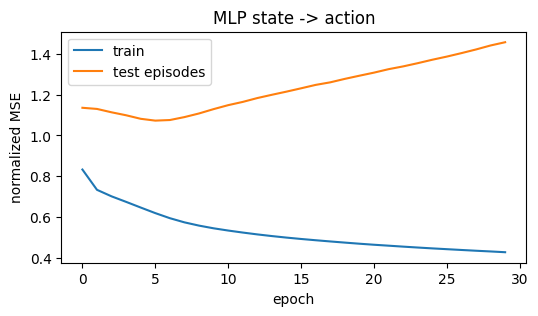

In [16]:
if not (flags["state"] and flags["actions"]) or len(episodes) < 5:
    print("Skipped: needs state + action fields and at least 5 scanned episodes.")
else:
    order = np.random.default_rng(SEED).permutation(len(episodes))
    n_test = max(1, len(order) // 5)
    test_idx, train_idx = order[:n_test], order[n_test:]
    Xtr = np.concatenate([episodes[i]["state"] for i in train_idx])
    Ytr = np.concatenate([episodes[i]["action"] for i in train_idx])
    Xte = np.concatenate([episodes[i]["state"] for i in test_idx])
    Yte = np.concatenate([episodes[i]["action"] for i in test_idx])
    Yprev = np.concatenate([np.vstack([episodes[i]["action"][:1], episodes[i]["action"][:-1]]) for i in test_idx])

    x_mu, x_sd = Xtr.mean(0), Xtr.std(0) + 1e-6
    y_mu, y_sd = Ytr.mean(0), Ytr.std(0) + 1e-6

    tf.keras.utils.set_random_seed(SEED)
    model = tf.keras.Sequential([
        tf.keras.layers.Input((Xtr.shape[1],)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(Ytr.shape[1]),
    ])
    model.compile(optimizer="adam", loss="mse")
    hist = model.fit((Xtr - x_mu) / x_sd, (Ytr - y_mu) / y_sd,
                     validation_data=((Xte - x_mu) / x_sd, (Yte - y_mu) / y_sd),
                     epochs=30, batch_size=256, verbose=0)
    pred = model.predict((Xte - x_mu) / x_sd, verbose=0) * y_sd + y_mu

    nmse = lambda P: float(np.mean(((P - Yte) / y_sd) ** 2))
    display(pd.DataFrame({
        "normalized MSE (lower is better)": {
            "mean action": nmse(np.broadcast_to(y_mu, Yte.shape)),
            "previous action": nmse(Yprev),
            "MLP(state)": nmse(pred),
        }}).round(4))

    r2 = 1 - ((pred - Yte) ** 2).sum(0) / (((Yte - Yte.mean(0)) ** 2).sum(0) + 1e-8)
    display(pd.Series(r2, index=ACTION_NAMES, name="R² per action dim").round(3).to_frame())

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(hist.history["loss"], label="train"); ax.plot(hist.history["val_loss"], label="test episodes")
    ax.set_xlabel("epoch"); ax.set_ylabel("normalized MSE"); ax.legend(); ax.set_title("MLP state -> action")
    plt.show()

## Step 14 — Dataset card for your thesis proposal

The next cell generates a summary you can paste into your proposal or discuss with your supervisor.

In [17]:
supported = report_df[report_df["status"] == "supported"]["topic"].tolist()
card = f"""
### Dataset summary: {info.name} v{info.version}

- **Format:** {"RLDS (episodes of steps)" if IS_RLDS else "flat examples"}; {TOTAL_EPISODES} training episodes
- **Episode length:** mean {ep_df['length'].mean():.0f}, min {ep_df['length'].min()}, max {ep_df['length'].max()} steps (from {len(episodes)} scanned episodes)
- **Cameras:** {', '.join(RGB_KEYS) or 'none'}{' | depth: ' + ', '.join(DEPTH_KEYS) if DEPTH_KEYS else ''}
- **Proprioception:** {len(STATE_NAMES)} dims ({', '.join(STATE_KEYS) or 'none'}){' | force/torque: ' + ', '.join(FORCE_KEYS) if FORCE_KEYS else ''}
- **Action space:** {len(ACTION_NAMES)} dims ({', '.join(ACTION_KEYS) or 'none'})
- **Language:** {N_UNIQUE_INSTR} unique instructions
- **Rewards / success labels:** {'yes' if HAS_REWARD_SIGNAL else 'no reward signal'} / {'yes' if HAS_SUCCESS_LABEL else 'no'}

**Thesis topics fully supported by the data:**
""" + "\n".join(f"{i + 1}. {t}" for i, t in enumerate(supported))
print(card)


### Dataset summary: robo_ai_u_r5e v1.0.0

- **Format:** RLDS (episodes of steps); 443 training episodes
- **Episode length:** mean 130, min 89, max 299 steps (from 52 scanned episodes)
- **Cameras:** observation/image
- **Proprioception:** 15 dims (observation/robot_state)
- **Action space:** 7 dims (action)
- **Language:** 20 unique instructions
- **Rewards / success labels:** no reward signal / no

**Thesis topics fully supported by the data:**
1. Unsupervised skill and sub-task segmentation
2. Trajectory forecasting and anomaly detection on proprioception
3. Fine-tuning a generalist robot foundation model (Octo / OpenVLA / pi0) + data-efficiency study
4. Language-conditioned visuomotor imitation learning (Diffusion Policy / ACT)
5. Action-conditioned world model / video prediction
6. Task success / failure detection and progress estimation from video
7. Multi-view and multi-sensor fusion for manipulation policies
8. Language grounding: instruction <-> video retrieval and task reco

## Next steps

1. **Run everything** and read the outputs of Steps 2, 6, 10 and 12. They decide most of the choice.
2. **Shortlist 2 topics** from the feasibility report and discuss them with your supervisor, together with the dataset card.
3. **Clarify robot access** (real UR5e or simulation). This decides between policy-learning and offline-evaluable topics.
4. **Read the core papers** for the chosen direction:
   - *Open X-Embodiment: Robotic Learning Datasets and RT-X Models* (2023) — the RLDS dataset ecosystem
   - *Octo* (2024), *OpenVLA* (2024), *π0* (2024) — generalist robot policies to fine-tune
   - *Diffusion Policy* (Chi et al., 2023), *ACT / ALOHA* (Zhao et al., 2023) — strong imitation-learning baselines
5. **Formulate the thesis as:** *problem → research question → baseline → proposed method → metrics → ablations*.
6. **Check the dataset license and citation** (Step 1) before publishing results.